# Multiclass DNN — Baseline + 10-Experiment Optimization

Mirrors the binary pipeline (`Binary_Baseline.ipynb` + `optimization.ipynb`), adapted for multi-class classification: Normal + 9 attack categories.

Import libraries

In [1]:
import os
import time
import random
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("../models", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
os.makedirs("../results", exist_ok=True)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


Check GPU availability

In [2]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:", gpus)
else:
    print("No GPU detected. Training will use the CPU.")


No GPU detected. Training will use the CPU.


Load preprocessed multiclass data (train/val/test, using the split already prepared in Preprocessing.ipynb)

In [3]:
X_train_final = np.load("../results/X_train_multi.npy").astype("float32")
X_val = np.load("../results/X_val_multi.npy").astype("float32")
X_test = np.load("../results/X_test_multi.npy").astype("float32")

y_train_final = np.load("../results/y_train_multi.npy").astype("int32")
y_val = np.load("../results/y_val_multi.npy").astype("int32")
y_test = np.load("../results/y_test_multi.npy").astype("int32")

class_names = np.load("../results/multiclass_names.npy", allow_pickle=True)
num_classes = len(class_names)

print("Training set  :", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Testing set   :", X_test.shape)
print("Number of classes:", num_classes)
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")


Training set  : (65865, 190)
Validation set: (16467, 190)
Testing set   : (175341, 190)
Number of classes: 10
  0: Analysis
  1: Backdoor
  2: DoS
  3: Exploits
  4: Fuzzers
  5: Generic
  6: Normal
  7: Reconnaissance
  8: Shellcode
  9: Worms


Examine class distribution

In [4]:
def class_distribution(labels, dataset_name, class_names):
    values, counts = np.unique(labels, return_counts=True)

    distribution = pd.DataFrame({
        "Class Number": values,
        "Attack Category": [class_names[v] for v in values],
        "Count": counts,
        "Percentage": np.round(counts / len(labels) * 100, 4)
    })

    print(dataset_name)
    display(distribution)


class_distribution(y_train_final, "Training distribution", class_names)
class_distribution(y_val, "Validation distribution", class_names)
class_distribution(y_test, "Testing distribution", class_names)


Training distribution


,Class Number,Attack Category,Count,Percentage
0,0,Analysis,542,0.8229
1,1,Backdoor,466,0.7075
2,2,DoS,3271,4.9662
3,3,Exploits,8905,13.5201
4,4,Fuzzers,4850,7.3635
5,5,Generic,15097,22.9211
6,6,Normal,29600,44.9404
7,7,Reconnaissance,2797,4.2466
8,8,Shellcode,302,0.4585
9,9,Worms,35,0.0531


Validation distribution


,Class Number,Attack Category,Count,Percentage
0,0,Analysis,135,0.8198
1,1,Backdoor,117,0.7105
2,2,DoS,818,4.9675
3,3,Exploits,2227,13.5240
4,4,Fuzzers,1212,7.3602
5,5,Generic,3774,22.9186
6,6,Normal,7400,44.9384
7,7,Reconnaissance,699,4.2449
8,8,Shellcode,76,0.4615
9,9,Worms,9,0.0547


Testing distribution


,Class Number,Attack Category,Count,Percentage
0,0,Analysis,2000,1.1406
1,1,Backdoor,1746,0.9958
2,2,DoS,12264,6.9944
3,3,Exploits,33393,19.0446
4,4,Fuzzers,18184,10.3706
5,5,Generic,40000,22.8127
6,6,Normal,56000,31.9378
7,7,Reconnaissance,10491,5.9832
8,8,Shellcode,1133,0.6462
9,9,Worms,130,0.0741


Compute class weights

The multi-class task is severely imbalanced (e.g. Worms/Backdoor have far fewer samples than Generic/Normal), so balanced class weights are used wherever `use_class_weights=True`.

In [5]:
class_labels = np.unique(y_train_final)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=y_train_final
)

class_weights = {int(label): float(weight) for label, weight in zip(class_labels, class_weight_values)}

print("Class weights:")
for label, weight in class_weights.items():
    print(f"  {class_names[label]}: {weight:.3f}")


Class weights:
  Analysis: 12.152
  Backdoor: 14.134
  DoS: 2.014
  Exploits: 0.740
  Fuzzers: 1.358
  Generic: 0.436
  Normal: 0.223
  Reconnaissance: 2.355
  Shellcode: 21.810
  Worms: 188.186


## Model factory

Function to build multiclass DNN models

In [6]:
def build_multiclass_model(
    input_dim,
    num_classes,
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=False,
    optimizer_name="adam",
    learning_rate=0.001
):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for index, neurons in enumerate(hidden_layers, start=1):
        model.add(tf.keras.layers.Dense(neurons, activation="relu", name=f"dense_{index}"))

        if use_batch_norm:
            model.add(tf.keras.layers.BatchNormalization(name=f"batch_norm_{index}"))

        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate, name=f"dropout_{index}"))

    model.add(tf.keras.layers.Dense(num_classes, activation="softmax", name="output"))

    optimizer_name = optimizer_name.lower()

    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


## Experiment function

Train and evaluate one experiment

In [7]:
experiment_results = []
experiment_histories = {}
trained_models = {}


def run_experiment(
    experiment_name,
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=False,
    optimizer_name="adam",
    learning_rate=0.001,
    use_class_weights=False,
    use_early_stopping=False,
    epochs=30,
    batch_size=256
):
    print("=" * 70)
    print("Running:", experiment_name)
    print("=" * 70)

    tf.keras.backend.clear_session()
    gc.collect()

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_multiclass_model(
        input_dim=X_train_final.shape[1],
        num_classes=num_classes,
        hidden_layers=hidden_layers,
        dropout_rate=dropout_rate,
        use_batch_norm=use_batch_norm,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate
    )

    callbacks = []
    if use_early_stopping:
        callbacks.append(
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True,
                verbose=1
            )
        )

    selected_class_weights = class_weights if use_class_weights else None

    start_time = time.time()

    history = model.fit(
        X_train_final,
        y_train_final,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=selected_class_weights,
        callbacks=callbacks,
        verbose=1,
        shuffle=True
    )

    training_time = time.time() - start_time

    probabilities = model.predict(X_test, batch_size=batch_size, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average="macro", zero_division=0)
    recall = recall_score(y_test, predictions, average="macro", zero_division=0)
    f1 = f1_score(y_test, predictions, average="macro", zero_division=0)

    result = {
        "Experiment": experiment_name,
        "Architecture": "-".join(map(str, hidden_layers)),
        "Hidden Layers": len(hidden_layers),
        "Dropout": dropout_rate,
        "Batch Normalization": use_batch_norm,
        "Optimizer": optimizer_name,
        "Learning Rate": learning_rate,
        "Class Weights": use_class_weights,
        "Early Stopping": use_early_stopping,
        "Epochs Completed": len(history.history["loss"]),
        "Batch Size": batch_size,
        "Parameters": model.count_params(),
        "Test Accuracy": accuracy,
        "Test Precision (macro)": precision,
        "Test Recall (macro)": recall,
        "Test F1 (macro)": f1,
        "Training Time Seconds": training_time
    }

    experiment_results.append(result)
    experiment_histories[experiment_name] = history.history
    trained_models[experiment_name] = model

    print("\nResults")
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision (macro) : {precision:.4f}")
    print(f"Recall (macro)    : {recall:.4f}")
    print(f"F1-score (macro)  : {f1:.4f}")
    print(f"Time              : {training_time:.2f} seconds")

    return model, history, result


## Experiment 1 — Baseline

In [8]:
_, _, result_1 = run_experiment(
    experiment_name="E1_Baseline",
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=False,
    optimizer_name="adam",
    learning_rate=0.001,
    use_class_weights=False,
    use_early_stopping=False,
    epochs=30,
    batch_size=256
)


Running: E1_Baseline

Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7283 - loss: 0.8554 - val_accuracy: 0.7736 - val_loss: 0.6195
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7912 - loss: 0.5640 - val_accuracy: 0.7930 - val_loss: 0.5407
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8162 - loss: 0.5063 - val_accuracy: 0.8125 - val_loss: 0.5086
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8283 - loss: 0.4801 - val_accuracy: 0.8227 - val_loss: 0.4922
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8340 - loss: 0.4652 - val_accuracy: 0.8286 - val_loss: 0.4823
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8372 - loss: 0.4549 - val_accuracy: 0.8326 - val_loss: 0.4743
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8395 - loss: 0.4469 - val_accuracy: 0.8359 - val_loss: 0.4684
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8415 - loss: 0.4

Experiment 2 — Network depth

Tested in isolation against the baseline (2 hidden layers): 1, 3, and 4 hidden layers, keeping every other factor at baseline defaults.

In [9]:
depth_candidates = [(128,), (128, 64, 32), (128, 64, 32, 16)]
depth_runs = [{"layers": (128, 64), "result": result_1}]

for layers in depth_candidates:
    _, _, res = run_experiment(
        experiment_name=f"E2_Depth_{len(layers)}L",
        hidden_layers=layers,
        dropout_rate=0.0,
        use_batch_norm=False,
        optimizer_name="adam",
        learning_rate=0.001,
        use_class_weights=False,
        use_early_stopping=False,
        epochs=30,
        batch_size=256
    )
    depth_runs.append({"layers": layers, "result": res})

best_depth_run = max(depth_runs, key=lambda r: r["result"]["Test F1 (macro)"])
print("Best depth found:", best_depth_run["layers"], "F1 =", best_depth_run["result"]["Test F1 (macro)"])


Running: E2_Depth_1L
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6999 - loss: 0.9612 - val_accuracy: 0.7481 - val_loss: 0.6983
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7669 - loss: 0.6445 - val_accuracy: 0.7665 - val_loss: 0.6216
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7856 - loss: 0.5833 - val_accuracy: 0.7826 - val_loss: 0.5806
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7974 - loss: 0.5456 - val_accuracy: 0.7888 - val_loss: 0.5536
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8102 - loss: 0.5199 - val_accuracy: 0.7966 - val_loss: 0.5360
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8195 - loss: 0.5023 - val_accuracy: 0.8039 - val_loss: 0.5242
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8250 - loss: 0.4896 - val_accuracy: 0.8096 - val_loss: 0.5158
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8296 - loss: 0.48

Experiment 3 — Layer width

Tested in isolation against the baseline (128, 64): narrower and wider 2-layer variants from 32 up to 512 neurons per layer.

In [10]:
width_candidates = [(32, 16), (64, 32), (256, 128), (512, 256)]
width_runs = [{"layers": (128, 64), "result": result_1}]

for layers in width_candidates:
    _, _, res = run_experiment(
        experiment_name=f"E3_Width_{'-'.join(map(str, layers))}",
        hidden_layers=layers,
        dropout_rate=0.0,
        use_batch_norm=False,
        optimizer_name="adam",
        learning_rate=0.001,
        use_class_weights=False,
        use_early_stopping=False,
        epochs=30,
        batch_size=256
    )
    width_runs.append({"layers": layers, "result": res})

best_width_run = max(width_runs, key=lambda r: r["result"]["Test F1 (macro)"])
print("Best width found:", best_width_run["layers"], "F1 =", best_width_run["result"]["Test F1 (macro)"])

best_architecture = (
    best_depth_run["layers"]
    if best_depth_run["result"]["Test F1 (macro)"] >= best_width_run["result"]["Test F1 (macro)"]
    else best_width_run["layers"]
)
print("\nArchitecture carried into Experiment 10:", best_architecture)


Running: E3_Width_32-16
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6330 - loss: 1.2424 - val_accuracy: 0.7340 - val_loss: 0.8099
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7593 - loss: 0.7228 - val_accuracy: 0.7607 - val_loss: 0.6751
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7735 - loss: 0.6383 - val_accuracy: 0.7761 - val_loss: 0.6235
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.7842 - loss: 0.5903 - val_accuracy: 0.7812 - val_loss: 0.5871
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7963 - loss: 0.5543 - val_accuracy: 0.7930 - val_loss: 0.5595
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 992us/step - accuracy: 0.8109 - loss: 0.5278 - val_accuracy: 0.7995 - val_loss: 0.5410
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - accuracy: 0.8201 - loss: 0.5092 - val_accuracy: 0.8063 - val_loss: 0.5275
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - accuracy: 0.8254 -

Experiment 4 — Dropout

Rates tested in isolation against the baseline architecture (128, 64).

In [11]:
dropout_candidates = [0.2, 0.3, 0.4, 0.5]
dropout_runs = []

for rate in dropout_candidates:
    _, _, res = run_experiment(
        experiment_name=f"E4_Dropout_{rate}",
        hidden_layers=(128, 64),
        dropout_rate=rate,
        use_batch_norm=False,
        optimizer_name="adam",
        learning_rate=0.001,
        use_class_weights=False,
        use_early_stopping=False,
        epochs=30,
        batch_size=256
    )
    dropout_runs.append({"rate": rate, "result": res})

best_dropout_run = max(dropout_runs, key=lambda r: r["result"]["Test F1 (macro)"])
best_dropout = best_dropout_run["rate"]
print("Best dropout rate found:", best_dropout, "F1 =", best_dropout_run["result"]["Test F1 (macro)"])


Running: E4_Dropout_0.2
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7013 - loss: 0.9264 - val_accuracy: 0.7722 - val_loss: 0.6357
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7803 - loss: 0.6095 - val_accuracy: 0.7919 - val_loss: 0.5558
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7987 - loss: 0.5481 - val_accuracy: 0.8028 - val_loss: 0.5225
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8132 - loss: 0.5139 - val_accuracy: 0.8141 - val_loss: 0.5031
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8204 - loss: 0.4960 - val_accuracy: 0.8232 - val_loss: 0.4843
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8273 - loss: 0.4814 - val_accuracy: 0.8286 - val_loss: 0.4753
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8305 - loss: 0.4694 - val_accuracy: 0.8335 - val_loss: 0.4646
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8343 - loss: 0

Experiment 5 — Batch normalization

Tested in isolation against the baseline (no batch norm).

In [12]:
_, _, result_5 = run_experiment(
    experiment_name="E5_BatchNorm",
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=True,
    optimizer_name="adam",
    learning_rate=0.001,
    use_class_weights=False,
    use_early_stopping=False,
    epochs=30,
    batch_size=256
)

best_use_batch_norm = result_5["Test F1 (macro)"] >= result_1["Test F1 (macro)"]
print("Batch norm improves F1 over baseline:", best_use_batch_norm)


Running: E5_BatchNorm
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7715 - loss: 0.6724 - val_accuracy: 0.7474 - val_loss: 1.0556
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8258 - loss: 0.4843 - val_accuracy: 0.7940 - val_loss: 0.5649
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8340 - loss: 0.4566 - val_accuracy: 0.8253 - val_loss: 0.4829
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8382 - loss: 0.4426 - val_accuracy: 0.8283 - val_loss: 0.4618
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8406 - loss: 0.4329 - val_accuracy: 0.8341 - val_loss: 0.4547
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8431 - loss: 0.4245 - val_accuracy: 0.8355 - val_loss: 0.4551
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8449 - loss: 0.4171 - val_accuracy: 0.8357 - val_loss: 0.4491
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8475 - loss: 0.4

Experiment 6 — Learning rate

Rates tested in isolation against the baseline architecture (128, 64) with Adam.

In [13]:
lr_candidates = [1e-2, 1e-4, 1e-5]
lr_runs = [{"lr": 0.001, "result": result_1}]

for lr in lr_candidates:
    _, _, res = run_experiment(
        experiment_name=f"E6_LR_{lr}",
        hidden_layers=(128, 64),
        dropout_rate=0.0,
        use_batch_norm=False,
        optimizer_name="adam",
        learning_rate=lr,
        use_class_weights=False,
        use_early_stopping=False,
        epochs=30,
        batch_size=256
    )
    lr_runs.append({"lr": lr, "result": res})

best_lr_run = max(lr_runs, key=lambda r: r["result"]["Test F1 (macro)"])
best_lr = best_lr_run["lr"]
print("Best learning rate found:", best_lr, "F1 =", best_lr_run["result"]["Test F1 (macro)"])


Running: E6_LR_0.01
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7813 - loss: 0.6045 - val_accuracy: 0.8089 - val_loss: 0.5157
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8285 - loss: 0.4675 - val_accuracy: 0.8244 - val_loss: 0.4863
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8372 - loss: 0.4408 - val_accuracy: 0.8169 - val_loss: 0.5014
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8409 - loss: 0.4277 - val_accuracy: 0.8326 - val_loss: 0.4629
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8442 - loss: 0.4194 - val_accuracy: 0.8342 - val_loss: 0.4572
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8458 - loss: 0.4129 - val_accuracy: 0.8434 - val_loss: 0.4274
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8483 - loss: 0.4045 - val_accuracy: 0.8448 - val_loss: 0.4244
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8495 - loss: 0.399

Experiment 7 — Optimizer

Compared in isolation against the baseline architecture and learning rate (Adam is the baseline itself).

In [14]:
optimizer_candidates = ["rmsprop", "sgd"]
optimizer_runs = [{"optimizer": "adam", "result": result_1}]

for opt in optimizer_candidates:
    _, _, res = run_experiment(
        experiment_name=f"E7_Optimizer_{opt}",
        hidden_layers=(128, 64),
        dropout_rate=0.0,
        use_batch_norm=False,
        optimizer_name=opt,
        learning_rate=0.001,
        use_class_weights=False,
        use_early_stopping=False,
        epochs=30,
        batch_size=256
    )
    optimizer_runs.append({"optimizer": opt, "result": res})

best_optimizer_run = max(optimizer_runs, key=lambda r: r["result"]["Test F1 (macro)"])
best_optimizer = best_optimizer_run["optimizer"]
print("Best optimizer found:", best_optimizer, "F1 =", best_optimizer_run["result"]["Test F1 (macro)"])


Running: E7_Optimizer_rmsprop
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7363 - loss: 0.8032 - val_accuracy: 0.7697 - val_loss: 0.6310
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7865 - loss: 0.5781 - val_accuracy: 0.7921 - val_loss: 0.5615
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8071 - loss: 0.5248 - val_accuracy: 0.7981 - val_loss: 0.5290
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8198 - loss: 0.4970 - val_accuracy: 0.8047 - val_loss: 0.5103
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8272 - loss: 0.4799 - val_accuracy: 0.8118 - val_loss: 0.5008
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8315 - loss: 0.4684 - val_accuracy: 0.8151 - val_loss: 0.4955
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8347 - loss: 0.4597 - val_accuracy: 0.8184 - val_loss: 0.4923
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8370 - l

Experiment 8 — Class weights

Tested in isolation against the baseline (no class weighting). Expected to matter more here than in the binary task, given how sparse some attack categories are.

In [15]:
_, _, result_8 = run_experiment(
    experiment_name="E8_ClassWeights",
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=False,
    optimizer_name="adam",
    learning_rate=0.001,
    use_class_weights=True,
    use_early_stopping=False,
    epochs=30,
    batch_size=256
)

best_use_class_weights = result_8["Test F1 (macro)"] >= result_1["Test F1 (macro)"]
print("Class weighting improves F1 over baseline:", best_use_class_weights)


Running: E8_ClassWeights
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5426 - loss: 1.6135 - val_accuracy: 0.6256 - val_loss: 0.9570
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6281 - loss: 1.2522 - val_accuracy: 0.6504 - val_loss: 0.8621
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6482 - loss: 1.1688 - val_accuracy: 0.6729 - val_loss: 0.8130
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6643 - loss: 1.1255 - val_accuracy: 0.7083 - val_loss: 0.7763
Epoch 5/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6790 - loss: 1.0996 - val_accuracy: 0.7369 - val_loss: 0.7381
Epoch 6/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6926 - loss: 1.0796 - val_accuracy: 0.7492 - val_loss: 0.7188
Epoch 7/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7044 - loss: 1.0642 - val_accuracy: 0.7482 - val_loss: 0.7035
Epoch 8/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7111 - loss: 

Experiment 9 — Early stopping

Tested in isolation against the baseline (no early stopping), patience=10 as in the proposal.

In [16]:
_, _, result_9 = run_experiment(
    experiment_name="E9_EarlyStopping",
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=False,
    optimizer_name="adam",
    learning_rate=0.001,
    use_class_weights=False,
    use_early_stopping=True,
    epochs=50,
    batch_size=256
)

best_use_early_stopping = result_9["Test F1 (macro)"] >= result_1["Test F1 (macro)"]
print("Early stopping improves F1 over baseline:", best_use_early_stopping)


Running: E9_EarlyStopping
Epoch 1/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7283 - loss: 0.8554 - val_accuracy: 0.7736 - val_loss: 0.6195
Epoch 2/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7912 - loss: 0.5640 - val_accuracy: 0.7930 - val_loss: 0.5407
Epoch 3/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8162 - loss: 0.5063 - val_accuracy: 0.8125 - val_loss: 0.5086
Epoch 4/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8283 - loss: 0.4801 - val_accuracy: 0.8227 - val_loss: 0.4922
Epoch 5/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8340 - loss: 0.4652 - val_accuracy: 0.8286 - val_loss: 0.4823
Epoch 6/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8372 - loss: 0.4549 - val_accuracy: 0.8326 - val_loss: 0.4743
Epoch 7/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8395 - loss: 0.4469 - val_accuracy: 0.8359 - val_loss: 0.4684
Epoch 8/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8415 - loss:

Experiment 10 — Final optimized model

Combines the single best value found for every factor in Experiments 2–9.

In [17]:
model_10, history_10, result_10 = run_experiment(
    experiment_name="E10_Final_Optimized",
    hidden_layers=best_architecture,
    dropout_rate=best_dropout,
    use_batch_norm=best_use_batch_norm,
    optimizer_name=best_optimizer,
    learning_rate=best_lr,
    use_class_weights=best_use_class_weights,
    use_early_stopping=best_use_early_stopping,
    epochs=100,
    batch_size=256
)

print("\nFinal configuration:")
print("  Architecture      :", best_architecture)
print("  Dropout            :", best_dropout)
print("  Batch normalization:", best_use_batch_norm)
print("  Learning rate      :", best_lr)
print("  Optimizer          :", best_optimizer)
print("  Class weights      :", best_use_class_weights)
print("  Early stopping     :", best_use_early_stopping)


Running: E10_Final_Optimized
Epoch 1/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7826 - loss: 0.6127 - val_accuracy: 0.7157 - val_loss: 0.8853
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8220 - loss: 0.4914 - val_accuracy: 0.8037 - val_loss: 0.5208
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8304 - loss: 0.4674 - val_accuracy: 0.8351 - val_loss: 0.4635
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8342 - loss: 0.4529 - val_accuracy: 0.8374 - val_loss: 0.4569
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8359 - loss: 0.4473 - val_accuracy: 0.8345 - val_loss: 0.4569
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8381 - loss: 0.4408 - val_accuracy: 0.8172 - val_loss: 0.4998
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8382 - loss: 0.4383 - val_accuracy: 0.8386 - val_loss: 0.4414
Epoch 8/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8

## Compare all experiments
Results table

In [18]:
results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values(by="Test F1 (macro)", ascending=False).reset_index(drop=True)
results_df


,Experiment,Architecture,Hidden Layers,Dropout,Batch Normalization,Optimizer,Learning Rate,Class Weights,Early Stopping,Epochs Completed,Batch Size,Parameters,Test Accuracy,Test Precision (macro),Test Recall (macro),Test F1 (macro),Training Time Seconds
0,E6_LR_0.01,128-64,2,0.0,False,adam,0.01000,False,False,30,256,33354,0.739439,0.509852,0.412301,0.417856,11.380838
1,E10_Final_Optimized,512-256,2,0.2,True,adam,0.01000,False,True,36,256,234762,0.749072,0.487451,0.403140,0.410145,52.031207
2,E3_Width_512-256,512-256,2,0.0,False,adam,0.00100,False,False,30,256,231690,0.738584,0.596529,0.412926,0.406944,27.290984
3,E5_BatchNorm,128-64,2,0.0,True,adam,0.00100,False,False,30,256,34122,0.735487,0.495119,0.404913,0.401023,14.337721
4,E2_Depth_4L,128-64-32-16,4,0.0,False,adam,0.00100,False,False,30,256,35482,0.739439,0.484119,0.402272,0.396874,12.299208
5,E3_Width_256-128,256-128,2,0.0,False,adam,0.00100,False,False,30,256,83082,0.737848,0.488145,0.404819,0.395036,15.065955
6,E9_EarlyStopping,128-64,2,0.0,False,adam,0.00100,False,True,50,256,33354,0.736017,0.479521,0.395117,0.386313,19.174963
7,E2_Depth_3L,128-64-32,3,0.0,False,adam,0.00100,False,False,30,256,35114,0.735532,0.469757,0.400565,0.386022,10.980739
8,E1_Baseline,128-64,2,0.0,False,adam,0.00100,False,False,30,256,33354,0.737386,0.458284,0.393865,0.380579,10.411241
9,E4_Dropout_0.2,128-64,2,0.2,False,adam,0.00100,False,False,30,256,33354,0.730582,0.467706,0.388056,0.373883,12.593081


Save results

In [19]:
results_df.to_csv("../results/multiclass_optimization_results.csv", index=False)
print("Optimization results saved.")


Optimization results saved.


## Plot experiment comparison
F1-score comparison

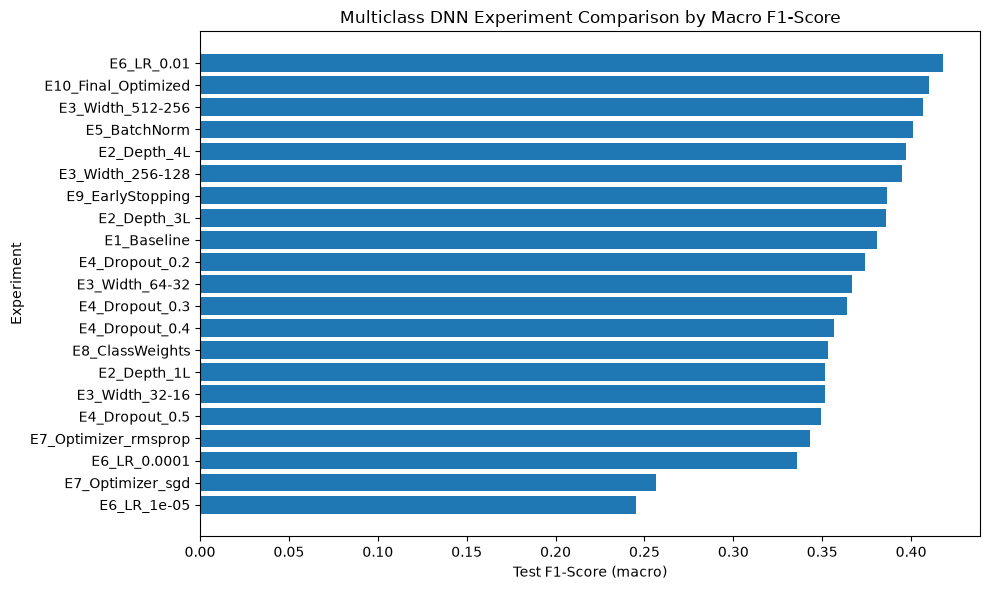

In [20]:
plot_df = results_df.sort_values("Test F1 (macro)", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Experiment"], plot_df["Test F1 (macro)"])
plt.title("Multiclass DNN Experiment Comparison by Macro F1-Score")
plt.xlabel("Test F1-Score (macro)")
plt.ylabel("Experiment")
plt.tight_layout()

plt.savefig("../figures/multiclass_experiment_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


Recall comparison

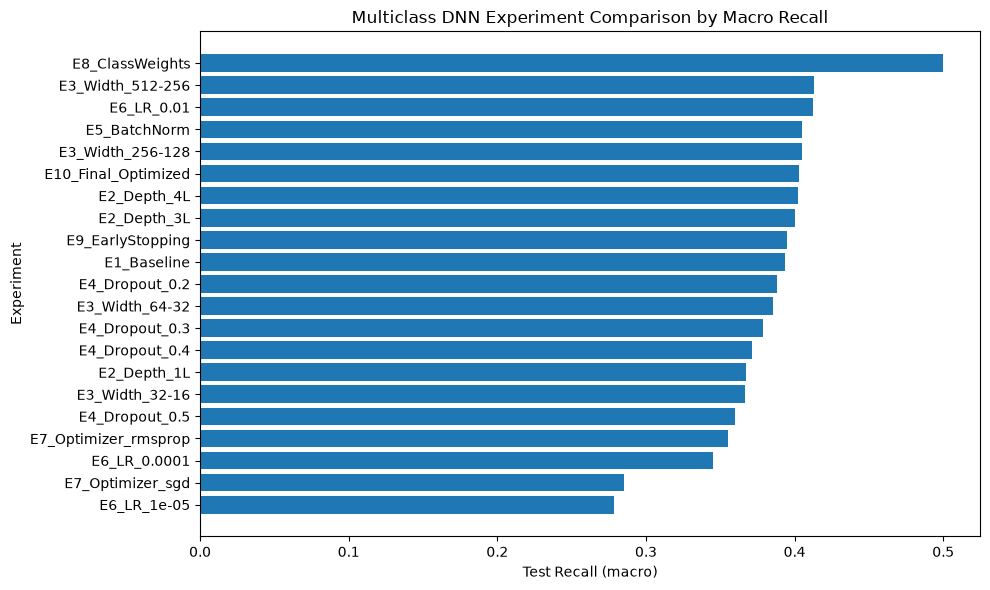

In [21]:
plot_df = results_df.sort_values("Test Recall (macro)", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Experiment"], plot_df["Test Recall (macro)"])
plt.title("Multiclass DNN Experiment Comparison by Macro Recall")
plt.xlabel("Test Recall (macro)")
plt.ylabel("Experiment")
plt.tight_layout()

plt.savefig("../figures/multiclass_experiment_recall_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


Accuracy, precision, recall and F1

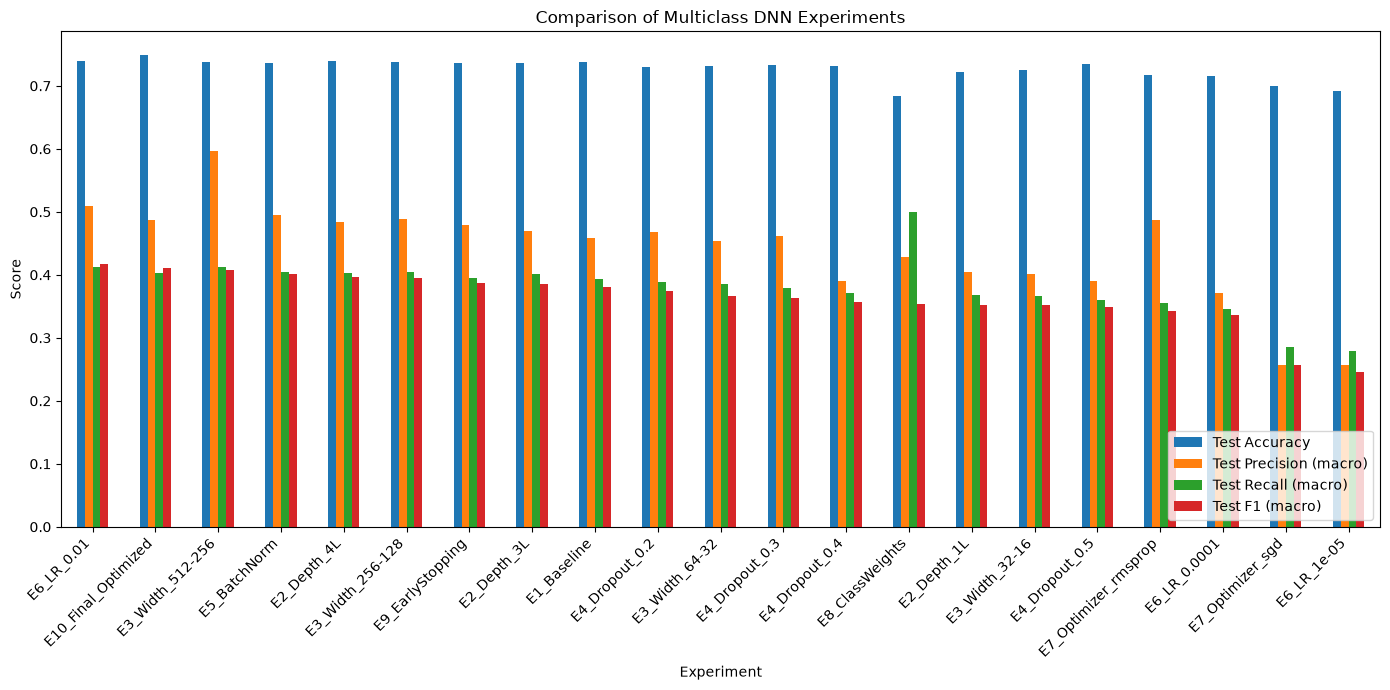

In [22]:
metrics_df = results_df.set_index("Experiment")[
    ["Test Accuracy", "Test Precision (macro)", "Test Recall (macro)", "Test F1 (macro)"]
]

metrics_df.plot(kind="bar", figsize=(14, 7))
plt.title("Comparison of Multiclass DNN Experiments")
plt.xlabel("Experiment")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig("../figures/multiclass_all_metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


Select the best model

In [23]:
best_experiment_name = results_df.iloc[0]["Experiment"]
print("Best experiment:", best_experiment_name)
print()
print(results_df.iloc[0])


Best experiment: E6_LR_0.01

Experiment                E6_LR_0.01
Architecture                  128-64
Hidden Layers                      2
Dropout                          0.0
Batch Normalization            False
Optimizer                       adam
Learning Rate                   0.01
Class Weights                  False
Early Stopping                 False
Epochs Completed                  30
Batch Size                       256
Parameters                     33354
Test Accuracy               0.739439
Test Precision (macro)      0.509852
Test Recall (macro)         0.412301
Test F1 (macro)             0.417856
Training Time Seconds      11.380838
Name: 0, dtype: object


In [24]:
best_model = trained_models[best_experiment_name]
best_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │        24,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,064 (390.88 KB)

 Trainable params: 33,354 (130.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 66,710 (260.59 KB)

In [25]:
best_model.save("../models/multiclass_optimized_best.keras")
print("Best optimized multiclass model saved successfully.")


Best optimized multiclass model saved successfully.


Best-model classification report

In [26]:
best_probabilities = best_model.predict(X_test, batch_size=256, verbose=0)
best_predictions = np.argmax(best_probabilities, axis=1)

best_report = classification_report(
    y_test,
    best_predictions,
    target_names=[str(c) for c in class_names],
    digits=4,
    zero_division=0
)

print(best_report)


                precision    recall  f1-score   support

      Analysis     0.0000    0.0000    0.0000      2000
      Backdoor     0.0000    0.0000    0.0000      1746
           DoS     0.3349    0.6511    0.4423     12264
      Exploits     0.7251    0.5792    0.6440     33393
       Fuzzers     0.6418    0.1298    0.2160     18184
       Generic     0.9851    0.9806    0.9828     40000
        Normal     0.7403    0.9774    0.8425     56000
Reconnaissance     0.8211    0.5470    0.6566     10491
     Shellcode     0.7348    0.2348    0.3559      1133
         Worms     0.1154    0.0231    0.0385       130

      accuracy                         0.7394    175341
     macro avg     0.5099    0.4123    0.4179    175341
  weighted avg     0.7432    0.7394    0.7109    175341



Save classification report

In [27]:
best_report_df = pd.DataFrame(
    classification_report(
        y_test,
        best_predictions,
        target_names=[str(c) for c in class_names],
        output_dict=True,
        zero_division=0
    )
).transpose()

best_report_df.to_csv("../results/multiclass_optimized_classification_report.csv")
best_report_df


,precision,recall,f1-score,support
Analysis,0.000000,0.000000,0.000000,2000.000000
Backdoor,0.000000,0.000000,0.000000,1746.000000
DoS,0.334941,0.651093,0.442333,12264.000000
Exploits,0.725142,0.579193,0.644002,33393.000000
Fuzzers,0.641750,0.129839,0.215981,18184.000000
Generic,0.985081,0.980550,0.982810,40000.000000
Normal,0.740269,0.977446,0.842484,56000.000000
Reconnaissance,0.821148,0.547040,0.656636,10491.000000
Shellcode,0.734807,0.234775,0.355853,1133.000000
Worms,0.115385,0.023077,0.038462,130.000000


Confusion matrix

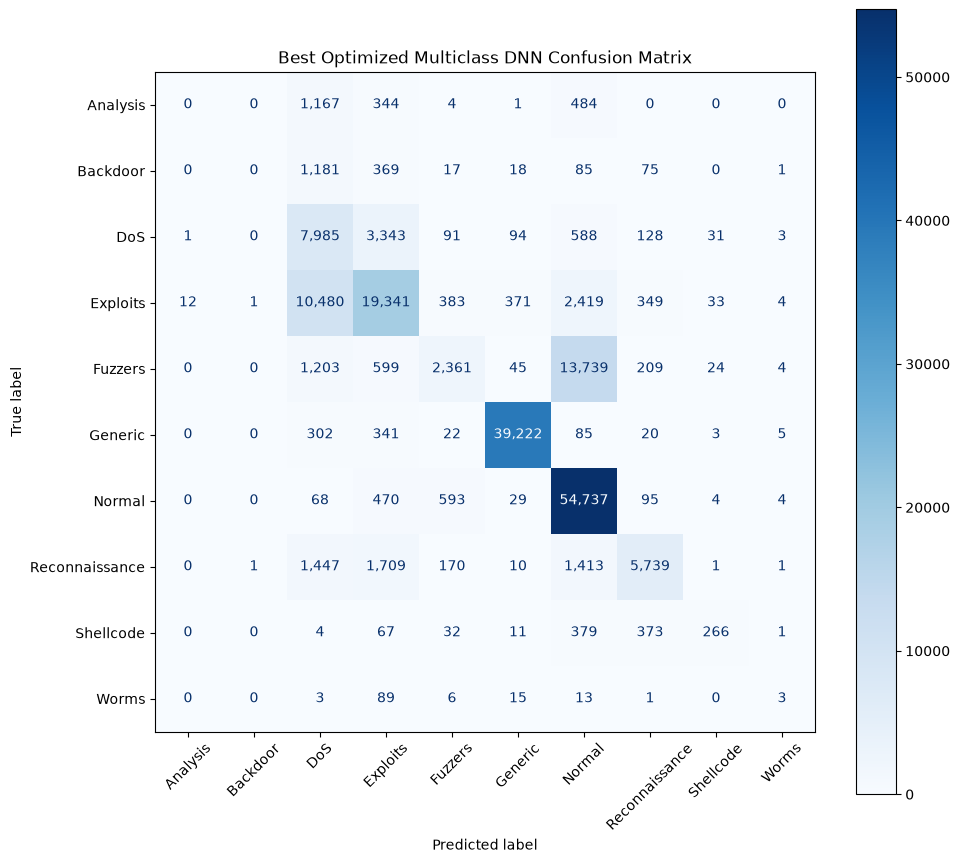

In [28]:
best_confusion_matrix = confusion_matrix(y_test, best_predictions)

fig, ax = plt.subplots(figsize=(10, 9))
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=best_confusion_matrix,
    display_labels=[str(c) for c in class_names]
)
display_matrix.plot(values_format=",", cmap="Blues", ax=ax, xticks_rotation=45)

plt.title("Best Optimized Multiclass DNN Confusion Matrix")
plt.tight_layout()

plt.savefig("../figures/multiclass_optimized_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


Plot best training history

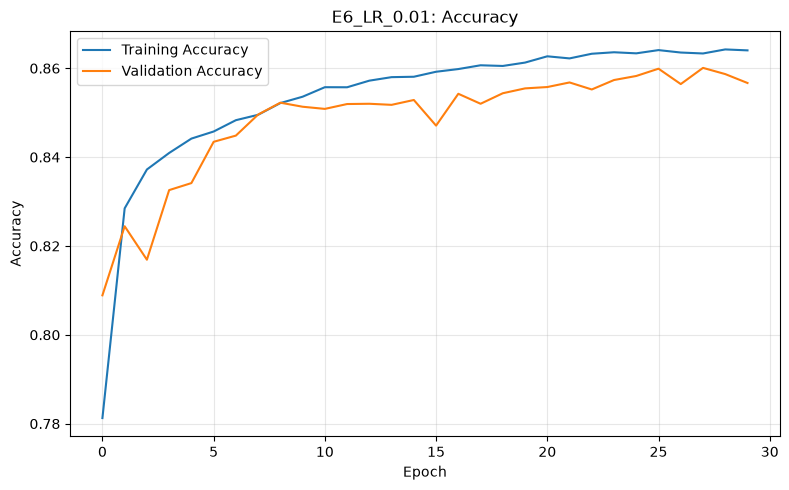

In [29]:
best_history = experiment_histories[best_experiment_name]

plt.figure(figsize=(8, 5))
plt.plot(best_history["accuracy"], label="Training Accuracy")
plt.plot(best_history["val_accuracy"], label="Validation Accuracy")
plt.title(f"{best_experiment_name}: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../figures/multiclass_optimized_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()


Best-model loss

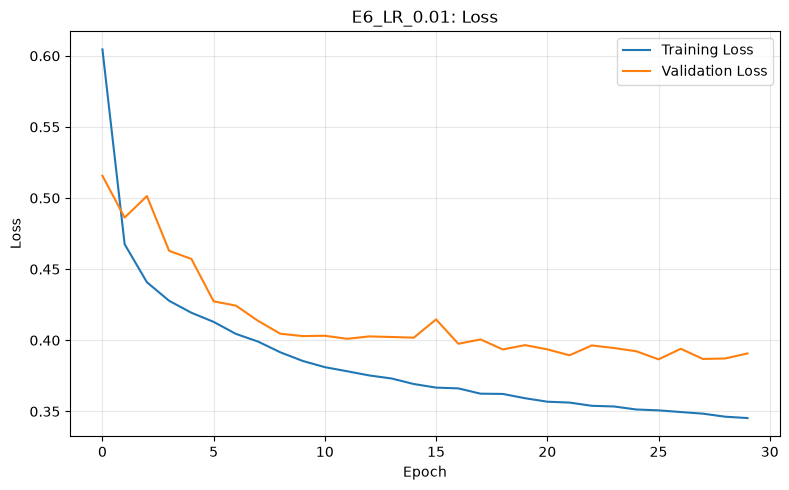

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(best_history["loss"], label="Training Loss")
plt.plot(best_history["val_loss"], label="Validation Loss")
plt.title(f"{best_experiment_name}: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../figures/multiclass_optimized_loss.png", dpi=300, bbox_inches="tight")
plt.show()
